In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [133]:
data = pd.read_csv('treino.csv')
data = np.array(data)
np.random.shuffle(data)
m, n = data.shape

data_train = data[:3000].T # (785, 1000)
data_test = data[3000:].T # (785, 41000)

Y_train = data_train[0] # (1000,)
X_train = data_train[1:]
X_train = X_train / 255  # (784, 1000)

Y_test = data_test[0] # (41000,)
X_test = data_test[1:]
X_test = X_test / 255 # (784, 41000)

In [134]:
def init_params():
    w0 = np.random.uniform(-0.5, 0.5, (10, 784))
    b0 = np.random.uniform(-0.5, 0.5, (10, 1))
    w1 = np.random.uniform(-0.5, 0.5, (10, 10))
    b1 = np.random.uniform(-0.5, 0.5, (10, 1))
    return w0, b0, w1, b1  

def relu(Z):
    A = np.maximum(Z, 0)
    return A

def d_relu(Z):
    return Z > 0

def softmax(Z):
    Z_shift = Z - np.max(Z, axis=0, keepdims=True)  # evita overflow
    exp_Z = np.exp(Z_shift)
    return exp_Z / np.sum(exp_Z, axis=0, keepdims=True)

def OH_encode(Y):
    onehot = np.zeros((Y.size, 10))
    onehot[np.arange(Y.size), Y] = 1
    return onehot.T

def forward(X, w0, b0, w1, b1):
    A0 = X
    Z1 = w0 @ A0 + b0
    A1 = relu(Z1)
    Z2 = w1 @ A1 + b1
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def back_prop(X, Y, Z1, A1, Z2, A2, w1):
    one_hot = OH_encode(Y)
    dz2 = A2 - one_hot
    dw1 = 1 / 30000 * dz2 @ A1.T
    db1 = 1 / 30000 * np.sum(dz2)
    dz1 = w1.T @ dz2 * d_relu(Z1)
    dw0 = 1 / 30000 * dz1 @ X.T
    db0 = 1 / 30000 * np.sum(dz1)
    return dw0, db0, dw1, db1

def atualiza(w0, b0, w1, b1, dw0, db0, dw1, db1, lr):
    w0 = w0 - lr * dw0
    b0 = b0 - lr * db0
    w1 = w1 - lr * dw1
    b1 = b1 - lr * db1
    return w0, b0, w1, b1

In [135]:
def predict(A2):
    return np.argmax(A2, 0)

def accuracy(predict, Y):
    return np.sum(predict == Y) / Y.size

def gradient(X, Y, lr, iter):
    w0, b0, w1, b1 = init_params()
    for i in range(iter):
        Z1, A1, Z2, A2 = forward(X, w0, b0, w1, b1)
        dw0, db0, dw1, db1 = back_prop(X, Y, Z1, A1, Z2, A2, w1)
        w0, b0, w1, b1 = atualiza(w0, b0, w1, b1, dw0, db0, dw1, db1, lr)
        
        if i % 100 == 0:
            print(f'Iteração: {i}')
            pred = predict(A2)
            print(f'Acurácia do modelo: {accuracy(pred, Y)}')
    return w0, b0, w1, b1

In [136]:
w0, b0, w1, b1 = gradient(X_train, Y_train, 0.8, 1001)

Iteração: 0
Acurácia do modelo: 0.1
Iteração: 100
Acurácia do modelo: 0.6193333333333333
Iteração: 200
Acurácia do modelo: 0.736
Iteração: 300
Acurácia do modelo: 0.786
Iteração: 400
Acurácia do modelo: 0.8186666666666667
Iteração: 500
Acurácia do modelo: 0.836
Iteração: 600
Acurácia do modelo: 0.8523333333333334
Iteração: 700
Acurácia do modelo: 0.8633333333333333
Iteração: 800
Acurácia do modelo: 0.8743333333333333
Iteração: 900
Acurácia do modelo: 0.8823333333333333
Iteração: 1000
Acurácia do modelo: 0.8886666666666667


[[ 0.00608882]
 [53.57320626]
 [22.44459298]
 [ 0.28876437]
 [ 0.00481809]
 [ 0.14082316]
 [22.13837525]
 [ 0.02938764]
 [ 1.22099251]
 [ 0.15295093]]
Prediction:  [1]
Label:  6


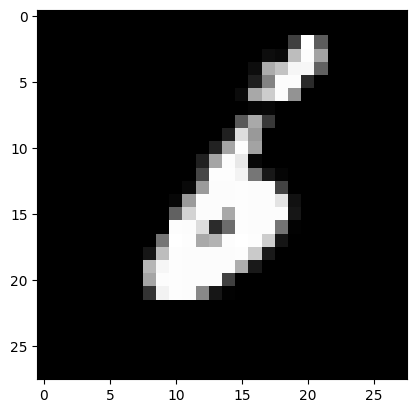

[[ 0.00016906]
 [ 0.        ]
 [ 0.00035322]
 [ 0.00230192]
 [ 0.00000013]
 [ 0.00002722]
 [ 0.        ]
 [99.98401367]
 [ 0.00000283]
 [ 0.01313196]]
Prediction:  [7]
Label:  7


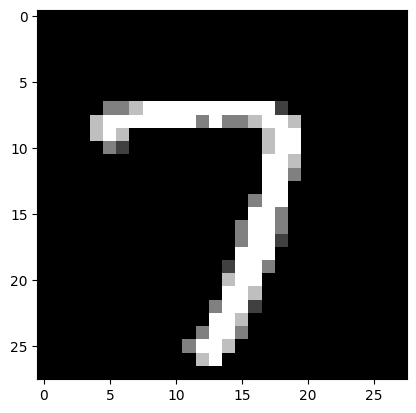

[[ 0.00065873]
 [ 0.65467843]
 [98.06803683]
 [ 0.46153615]
 [ 0.00000077]
 [ 0.04451541]
 [ 0.09991876]
 [ 0.00012464]
 [ 0.66933674]
 [ 0.00119354]]
Prediction:  [2]
Label:  2


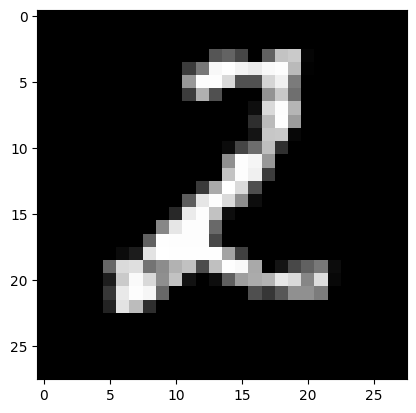

In [150]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward(X, W1, b1, W2, b2)
    np.set_printoptions(suppress=True)
    print(A2*100)
    predictions = predict(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_test[:, index, None]
    prediction = make_predictions(X_test[:, index, None], W1, b1, W2, b2)
    label = Y_test[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

imagens = np.random.randint(30000, 39000, 3)
for i in imagens:
    test_prediction(i, w0, b0, w1, b1)
